In [70]:
import matplotlib.pyplot as plt
import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [71]:
# PLOT THE PROBABILITIES IN EACH STATE AND STORAGE S
def plot_probs(time, prob_g, prob_e, prob_s, S):
    fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
    axs[0].plot(time, prob_g + prob_e + prob_s, color='red', label='Total')
    axs[0].plot(time, prob_g, color='blue', label='Ground')
    axs[0].set_ylabel('Probability')
    axs[0].set_title('Ground State Probability')
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(time, prob_s, color='orange')
    axs[1].set_ylabel('Probability')
    axs[1].set_title('Storage State Probability')
    axs[1].grid()

    axs[2].plot(time, prob_e, color='green')
    axs[2].set_xlabel('Time')
    axs[2].set_ylabel('Probability')
    axs[2].set_title('Excited State Probability')
    axs[2].grid()
    
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(time, abs(S), label='|S|')
    plt.plot(time, np.real(S), label='Re(S)')
    plt.plot(time, np.imag(S), label='Im(S)')
    plt.xlabel('Time')
    plt.ylabel('S')
    plt.legend()
    plt.grid()
    plt.show()

In [72]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ee = Qobj([[0,0,0],[0,0,0],[0,0,1]])  # |e><e| (excited state population)
sigma_ss = Qobj([[0,0,0],[0,1,0],[0,0,0]])  # |s><s| (storage state population)
sigma_gg = Qobj([[1,0,0],[0,0,0],[0,0,0]])  # |g><g| (ground state population)

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

## Hamiltonian 

$$ H = (\kappa_{ge} \alpha_{in}(t) \hat{a}^\dagger_{ge} + h.c.) + (\kappa_{se} \beta(t) \hat{a}^\dagger_{se} + h.c.) + 
g_{ge}(\hat{a}_{ge} \hat{\sigma}_{ge} + h.c.) + g_{se}(\hat{a}_{se} \hat{\sigma}_{se} + h.c.) + \Delta \hat{\sigma}_{ee} $$


- $\alpha_{in}(t)$: incoming signal (interacts with cavity operators denoted by $\hat{a}_{ge}$) coming from a bath
    - $[\alpha_{in}(t)]=\sqrt{Hz}$
- $\beta(t)$: applied coupling (interacts with cavity operators denoted by $\hat{a}_{se}$). 
    - See below for units analysis.
- $\kappa_{ge},\kappa_{se}$: cavity bandwidth (coupling between the cavity and bath)
    - $[\kappa_{ge}] = \sqrt{Hz}$
    - $[\kappa_{se}] = \sqrt{Hz}$
- $\hat{\sigma} $: raising/lowering operators in the atom for different states. Unitless. 
- $\hat{a}/\hat{a}^\dagger$: bosonic quantum operator in a cavity (for the different states). NOT a bath operator. Unitless.

- $g_{ge} = \sqrt{2\gamma_{ge} C_{ge}}$ in free space. Similarly, $g_{se}= \sqrt{2\gamma_{se} C_{se}}$. 
    - Note: $C$ can be denoted $C_w$ because it is dependent on beam size. 
    - $g_{ge} = Hz$ (amplitude scaling)
    - $g_{se} = Hz$ (amplitude scaling)

#### Converting $\beta(t)$
Because $\kappa_{se}$ has units of $\sqrt{Hz}$, we must convert the $\beta(t)$ term into the proper units of $\sqrt{Hz}$ (field strength = power scaling?). All terms in the Hamiltonian should have consistent units in terms of amplitude scaling. First, recall that for arbitrary quantities $g_{\text{cav}}$ and $g_{\text{no cav}}$ which are under the scalings shown below:
$$g_{\text{cav}} = \frac{g_{\text{no cav}}}{2} \cdot \frac{\kappa}{2} $$
- $g_{\text{cav}}$ is under amplitude scaling (units $\text{Hz}$)
- $g_{\text{no cav}}$ is under power scaling (units $\sqrt{\text{Hz}}$). 
- $\kappa$ is under power scaling because $\alpha_{in}$ is a bath term (units $\sqrt{\text{Hz}}$).
- Amplitude $\to$ power scaling: multiply by factor of 2


To adjust our freespace, $\Omega(t)$ to this $\beta(t)$:

$$\Omega(t) = g_{\text{no cav}} \cdot \beta(t) = 2\left(\frac{2}{\kappa} g_{cav}\right) \cdot \beta(t) = \frac{4}{\kappa_{se}} \cdot g_{se} \cdot \beta(t) $$

- Reminder: $[\Omega(t)]$ has units Hz (amplitude). Units check: $[\Omega(t)] = \frac{[g_{se}]}{[\kappa_{se}]} [\beta(t)] \to \text{Hz} = \frac{Hz}{\sqrt{Hz}} [\beta(t)] \to [\beta(t)] = \sqrt{Hz}$

$$\beta(t)=\Omega(t)\cdot \frac{\kappa_{se}}{4g_{se}}$$

### Decay Terms
The decay terms are then given by cavity relaxation (whose rate is denoted by $\kappa$). We assume no thermal photons because at least for 780 nm, the thermal background is negligible.

$$ L = [\kappa_{ge} \hat{a}_{ge}, \kappa_{se} \hat{a}_{se}, -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg}] $$

In the TLS cavity, we did not include a spontaneous decay terms like $g\hat{\sigma}_-$ because we asserted that atom will decay into the cavity rather than into an incoherent decay channel (free space). However, here we do include it because we have cooperativity involved, which requires us to account for decay into the cavity vs. spontaneous decay into external bath. 

In [73]:
# define cavity Hilbert space dimensions (same for both ge and se)
N_cav = 6

# cavity annihilation operators in full atom+cavity space
a_ge = tensor(destroy(N_cav), qeye(N_cav), qeye(3))
a_se = tensor(qeye(N_cav), destroy(N_cav), qeye(3))

# Atomic operators in full atom+cavity space
sig_ee_full = tensor(qeye(N_cav), qeye(N_cav), sigma_ee)
sig_ss_full = tensor(qeye(N_cav), qeye(N_cav), sigma_ss)
sig_gg_full = tensor(qeye(N_cav), qeye(N_cav), sigma_gg)

sig_ge_full = tensor(qeye(N_cav), qeye(N_cav), sigma_ge)
sig_eg_full = tensor(qeye(N_cav), qeye(N_cav), sigma_eg)

sig_se_full = tensor(qeye(N_cav), qeye(N_cav), sigma_se)
sig_es_full = tensor(qeye(N_cav), qeye(N_cav), sigma_es)

sig_gs_full = tensor(qeye(N_cav), qeye(N_cav), sigma_gs)
sig_sg_full = tensor(qeye(N_cav), qeye(N_cav), sigma_sg)

Input photon number: 0.00999999999999231
Pulse duration: 3.0326065213042606


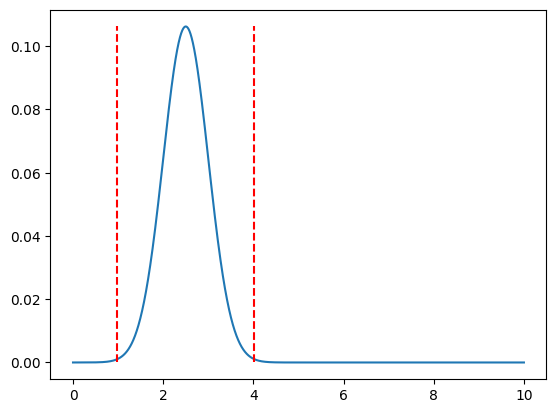

In [74]:
time_final = 10 # total time we will simulate for
N = 5000 # number of time steps

mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    return amp*(gaussian(mu, sigma, t)) 

time = np.linspace(0, time_final, N)
alpha = alpha_in(time) # input signal
input_photon_number = integrate.simps(alpha**2, time)
print("Input photon number:", input_photon_number)

def get_pulse_duration(alpha_in, time, threshold=0.01):
    max_amplitude = np.max(np.abs(alpha_in(time)))
    significant_indices = np.where(np.abs(alpha_in(time)) > threshold * max_amplitude)[0]
    if len(significant_indices) == 0:
        return 0, 0
    t_start = time[significant_indices[0]]
    t_end = time[significant_indices[-1]]
    duration = t_end - t_start

    return t_start, t_end, duration

t_start, t_end, T = get_pulse_duration(alpha_in, time) # T = pulse duration
print('Pulse duration:', T)
plt.plot(time, alpha_in(time))
plt.vlines([t_start, t_end], 0, max(alpha), color='red', linestyle='--', label='Pulse Duration')

In [75]:
# Simulation Time
time_final = 10 # total simulation time
N = 5000 # number of time steps

# System Parameters 
C_se = 100           # cooperativity (higher = more efficient)
C_ge = 100

gamma_se = 1       # decay rate
gamma_ge = 1       # decay rate
Delta = 700        # detuning

# cavity parameters
kappa_ge = 10
kappa_se = 10

g_se = np.sqrt(2*C_se*gamma_se) * kappa_se/2 # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C_ge*gamma_ge) * kappa_ge/2 # coupling strength between |g> and |e>

### Compute $\beta(t)$:

In [76]:
# Precompute prefactors (constants)
a = -(gamma_se*(1+C_se) - 1j*Delta) / np.sqrt(2*gamma_se*(1+C_se))
c = gamma_se**2*(1+C_se)**2 + Delta**2

# Compute b
b = [0]
for i in range(1, len(time)):
    integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i]) # integral (0 to t) of |alpha|^2
    if (integral_val == 0):
        b.append(0)
    else:      
        b.append(alpha[i] / (np.sqrt(integral_val)))
b = np.array(b)

In [77]:
# Returns the integral of |beta(t)|^2 from t[idx] to t[end_of_pulse]
def get_h(beta_vals, idx, time):
    T_index = np.where(time > T)[0][0] # find closest index corresponding to time T
    if idx >= T_index:
        h_val = 0
    else:
        h_val = integrate.simps(np.abs(beta_vals[idx:T_index])**2, time[idx:T_index]) # Integrate beta from time[idx] to time[T_index]

    return h_val

100%|██████████| 4999/4999 [00:00<00:00, 16757.34it/s]


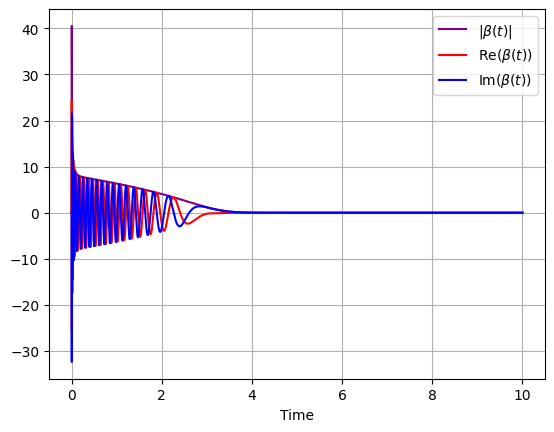

In [78]:
beta_vals = np.array([0])
h_vals = np.array([0])

for idx in tqdm(range(0, len(time)-1)):
    h = get_h(a*b, idx, time)
    if np.imag(h) != 0: print('Imaginary part detected')
    beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c) * kappa_se / (4*g_se)) # added scaling for beta 
    h_vals = np.append(h_vals, h)

def beta(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, beta_vals)  # Interpolate smoothed g values    
    
plt.plot(time, abs(beta_vals), color='purple', label=r'$|\beta(t)|$')
plt.plot(time, np.real(beta_vals), color='red', label=r'Re$(\beta(t))$')
plt.plot(time, np.imag(beta_vals), color='blue', label=r'Im$(\beta(t))$')
plt.xlabel('Time')
plt.grid()
plt.legend()

## Hamiltonian 

$$ H = (\kappa_{ge} \alpha_{in}(t) \hat{a}^\dagger_{ge} + h.c.) + (\kappa_{se} \beta_{in}(t) \hat{a}^\dagger_{se} + h.c.) + 
g_{ge}(\hat{a}_{ge} \hat{\sigma}_{ge} + h.c.) + g_{se}(\hat{a}_{se} \hat{\sigma}_{se} + h.c.) + \Delta \hat{\sigma}_{ee} $$

In [79]:
### ---------------------------- HAMILTONIAN ---------------------
H0 = Delta * sig_ee_full
H_int = g_ge * (a_ge*sig_ge_full + a_ge.dag()*sig_eg_full) + g_se * (a_se*sig_se_full + a_se.dag()*sig_es_full)
H_drive = [[a_ge.dag(), lambda t, args: kappa_ge*alpha_in(t)],
           [a_ge,       lambda t, args: np.conjugate(kappa_ge) * np.conjugate(alpha_in(t))],
           [a_se.dag(), lambda t, args: kappa_se * beta(t)],
           [a_se,       lambda t, args: np.conjugate(kappa_se) * np.conjugate(beta(t))]]
H = [[H0, 1], [H_int, 1]] + H_drive

### -------------------- COLLAPSE OPERATORS ---------------------
c_ops = [kappa_ge*a_ge, kappa_se*a_se,  -1/np.sqrt(C_ge)*sig_eg_full] # -np.conjugate(g_ge)*sig_eg_full,

### -------------------- SIMULATE ---------------------
# initial state: atom in ground state, both cavities empty
psi0 = tensor(basis(N_cav, 0), basis(N_cav, 0), ground)

# expectation operators
e_ops = [sig_ee_full, sig_ss_full, sig_gg_full, # excited/storage/ground state population
         sig_gs_full,  # S
         a_ge.dag() * a_ge, a_se.dag() * a_se] # number of photons in ge.se cavity

result = mesolve(H, psi0, time, c_ops, e_ops=e_ops)

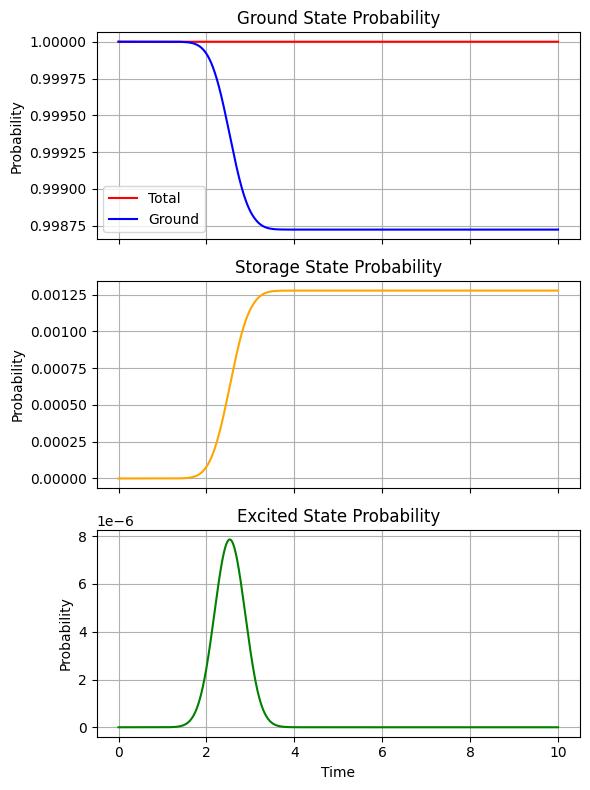

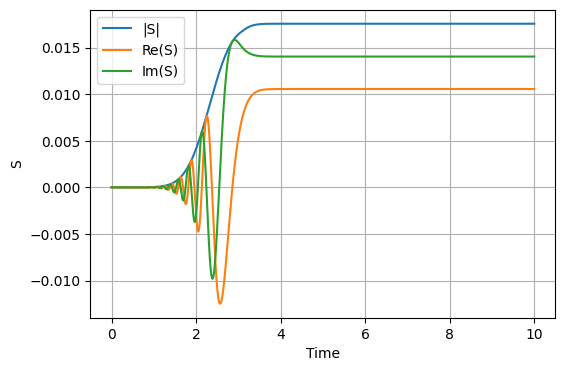

In [80]:
prob_e = result.expect[0]
prob_s = result.expect[1]
prob_g = result.expect[2]
S = result.expect[3]
plot_probs(time, prob_g, prob_e, prob_s, S)

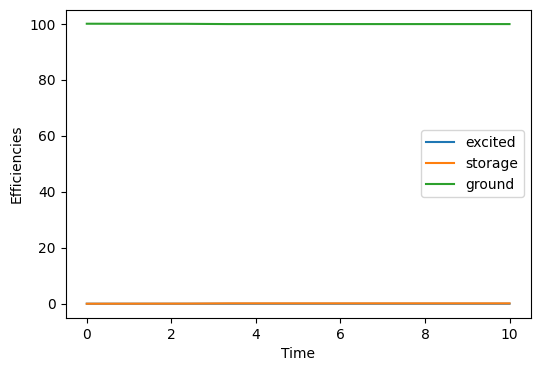

In [81]:
plt.figure(figsize=(6,4))
plt.plot(time, prob_e/input_photon_number, label='excited')
plt.plot(time, prob_s/input_photon_number, label='storage')
plt.plot(time, prob_g/input_photon_number, label='ground')
plt.xlabel('Time')
plt.ylabel('Efficiencies')
plt.legend()